# Ajustes iniciales notebook

In [1]:
from dotenv import load_dotenv
import os

# Carga las variables del archivo .env automáticamente
load_dotenv()

# Ahora puedes acceder a ellas
yolo_path = os.getenv("YOLO_CONFIG_DIR")
%env YOLO_CONFIG_DIR={yolo_path}

print(f"Configuración cargada desde .env: {yolo_path}")

env: YOLO_CONFIG_DIR=../models
Configuración cargada desde .env: ../models


In [2]:
import torch, cv2, numpy as np
from ultralytics import YOLO
import supervision as sv
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
if device == "cuda":
    #print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
    pass

Dispositivo: cuda


In [3]:
from ultralytics import settings
settings.update({"weights_dir": yolo_path})
print(settings['weights_dir'])

../models


# Workflow: Deteccion en Imagen

In [4]:
from ultralytics import YOLO
import supervision as sv
import cv2

In [6]:
model = YOLO("yolo26m.pt") #modelo yolo26 para analisis deportivo

In [7]:
result = model.predict("partido1.png", device="cuda", conf=0.5, imgsz=640, verbose=False)[0] #analizar imagen

In [8]:
# Acceder a detecciones
for box in result.boxes:
    cls_name = model.names[int(box.cls[0])]
    conf = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    print(f"{cls_name}: {conf:.2f} @ [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")

person: 0.94 @ [1548,591,1597,726]
person: 0.91 @ [1312,372,1357,482]
person: 0.91 @ [1675,601,1735,729]
person: 0.90 @ [326,342,385,450]
person: 0.90 @ [392,717,443,838]
person: 0.89 @ [150,689,239,820]
person: 0.89 @ [1698,291,1747,398]
person: 0.88 @ [1431,360,1460,475]
person: 0.86 @ [576,342,620,445]
person: 0.85 @ [1597,420,1642,535]
person: 0.84 @ [1079,382,1112,488]
person: 0.82 @ [1627,283,1656,387]
person: 0.82 @ [654,403,723,503]
person: 0.78 @ [1481,176,1515,279]
person: 0.78 @ [1386,173,1414,258]


In [9]:
# Visualizacion con Supervision
image = cv2.imread("partido1.png")
detections = sv.Detections.from_ultralytics(result)
labels = [f"{model.names[c]} {conf:.2f}" for c, conf in zip(detections.class_id, detections.confidence)]

annotated = sv.BoxAnnotator(thickness=2).annotate(scene=image.copy(), detections=detections)
annotated = sv.LabelAnnotator(text_scale=0.5).annotate(scene=annotated, detections=detections, labels=labels)
cv2.imwrite("resultado.jpg", annotated)

image_res = cv2.imread("resultado.jpg")

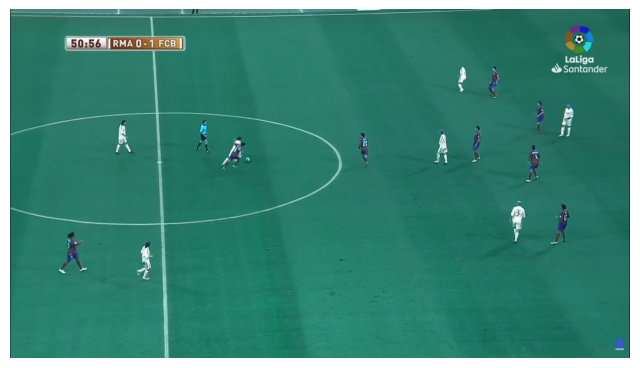

In [10]:
plt.figure(figsize=(8, 5))
plt.imshow(image)
plt.axis(False)
plt.show()

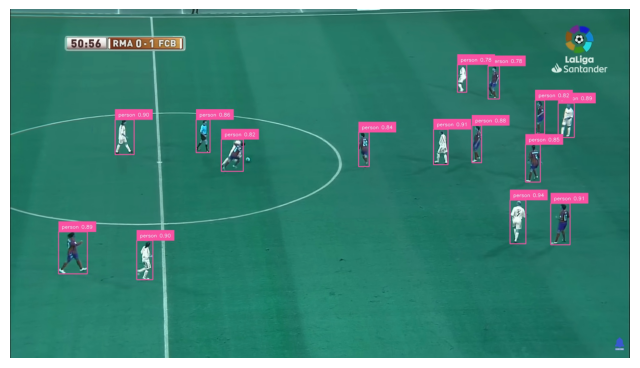

In [11]:
plt.figure(figsize=(8, 5))
plt.imshow(image_res)
plt.axis(False)
plt.show()

# Workflow: Deteccion en Video

In [12]:
video_path = "partido.mp4"
video_info = sv.VideoInfo.from_video_path(video_path)

box_ann = sv.BoxAnnotator(thickness=2)
label_ann = sv.LabelAnnotator(text_scale=0.5)

In [13]:
video_info

VideoInfo(width=1024, height=576, fps=30, total_frames=1396)

In [13]:
with sv.VideoSink(target_path="salida.mp4", video_info=video_info) as sink:
    for frame in sv.get_video_frames_generator(source_path=video_path): #iterar en los frames del video original
        #analiza cada frame y dibujar cajas
        result = model.predict(frame, device="cuda", conf=0.5, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(result)
        labels = [f"{model.names[c]} {conf:.2f}" for c, conf in zip(detections.class_id, detections.confidence)]

        annotated = box_ann.annotate(scene=frame.copy(), detections=detections)
        annotated = label_ann.annotate(scene=annotated, detections=detections, labels=labels)

        #agregar frame con dibujo al video final
        sink.write_frame(annotated)

# Workflow: Deteccion en Webcam

In [21]:
model = YOLO("yolo26n.pt")  # nano para real-time
box_ann, label_ann = sv.BoxAnnotator(thickness=2), sv.LabelAnnotator(text_scale=0.5)


cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    result = model.predict(frame, device="cuda", conf=0.5, verbose=False, classes=[67])[0] #solo detecta celulares

    detections = sv.Detections.from_ultralytics(result)
    labels = [f"{model.names[c]} {conf:.2f}" for c, conf in zip(detections.class_id, detections.confidence)]
    annotated = box_ann.annotate(scene=frame.copy(), detections=detections)
    annotated = label_ann.annotate(scene=annotated, detections=detections, labels=labels)
    cv2.imshow("YOLO", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"): break

cap.release()
cv2.destroyAllWindows()

# Detectar equipos deportivos

In [18]:
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import supervision as sv
from ultralytics import YOLO
import umap
from sklearn.cluster import KMeans
import numpy as np
from PIL import Image

# 1. Configuración Inicial
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = YOLO("yolov8l.pt")

# Extractor ResNet50 en CUDA
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
embedding_extractor = nn.Sequential(*list(resnet50.children())[:-1]).to(device).eval()

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_embedding(crop_img):
    img_pil = Image.fromarray(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
    img_t = preprocess(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        vector = embedding_extractor(img_t)
    return vector.detach().cpu().flatten().numpy()

video_path = "ARG_COL_HQ.mp4"
temp_detections = [] # Guardaremos info temporalmente
all_embeddings = []

# --- PASO 1: Extracción de Características ---
print("Paso 1: Analizando video y extrayendo embeddings...")
for frame_idx, frame in enumerate(sv.get_video_frames_generator(source_path=video_path)):
    result = model.predict(frame, device=device, conf=0.5, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    
    frame_crops_info = []
    for i in range(len(detections)):
        x1, y1, x2, y2 = detections.xyxy[i].astype(int)
        crop = frame[y1:y2, x1:x2]
        
        if crop.size > 0:
            emb = get_embedding(crop)
            all_embeddings.append(emb)
            # Guardamos la referencia para el segundo paso
            frame_crops_info.append(len(all_embeddings) - 1) 
        else:
            frame_crops_info.append(None)
            
    temp_detections.append((detections, frame_crops_info))

# --- PASO 2: Clustering (Definir Equipos) ---
print("Paso 2: Ejecutando UMAP y KMeans para separar equipos...")
embeddings_array = np.array(all_embeddings)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=5, random_state=42)
embeddings_low = reducer.fit_transform(embeddings_array)

# Entrenamos para 3 clusters (Equipo A, Equipo B y Equipo C)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_low)

# Mapeo de clusters a nombres
team_mapping = {0: "Equipo A", 1: "Equipo B", 2: "Equipo C"}  # Agregamos opción para detecciones sin embedding válido

# --- PASO 3: Generación de Video Final ---
print("Paso 3: Escribiendo video final con etiquetas de equipo...")
video_info = sv.VideoInfo.from_video_path(video_path)
box_ann = sv.BoxAnnotator()
label_ann = sv.LabelAnnotator(text_scale=0.5, text_padding=5)

with sv.VideoSink(target_path="resultado_equipos.mp4", video_info=video_info) as sink:
    # Re-iteramos usando la info guardada para no repetir inferencia YOLO
    generator = sv.get_video_frames_generator(source_path=video_path)
    
    for (frame, (detections, embedding_indices)) in zip(generator, temp_detections):
        custom_labels = []
        
        for idx in embedding_indices:
            if idx is not None:
                cluster = cluster_labels[idx]
                team_name = team_mapping[cluster]
                
                custom_labels.append(team_name)
            else:
                custom_labels.append("Desconocido")

        # Anotamos y guardamos
        annotated = box_ann.annotate(scene=frame.copy(), detections=detections)
        annotated = label_ann.annotate(scene=annotated, detections=detections, labels=custom_labels)
        sink.write_frame(annotated)

print("¡Listo! El video ha sido generado como 'resultado_equipos.mp4'.")

Paso 1: Analizando video y extrayendo embeddings...
Paso 2: Ejecutando UMAP y KMeans para separar equipos...


Paso 3: Escribiendo video final con etiquetas de equipo...
¡Listo! El video ha sido generado como 'resultado_equipos.mp4'.
